# Heart Failure Prediction Dataset: Exploratory Data Analysis (EDA)

*Dastan Abdildin, ITMO 2026*

Welcome to this comprehensive Exploratory Data Analysis (EDA) on the **Heart Failure Prediction dataset**!

### The Dataset Features:
Here is a quick overview of our clinical variables (features) available from [Kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data):

* **Age**: age of the patient [years]
* **Sex**: sex of the patient [M: Male, F: Female]
* **ChestPainType**: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
* **RestingBP**: resting blood pressure [mm Hg]
* **Cholesterol**: serum cholesterol [mm/dl]
* **FastingBS**: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
* **RestingECG**: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
* **MaxHR**: maximum heart rate achieved [Numeric value between 60 and 202]
* **ExerciseAngina**: exercise-induced angina [Y: Yes, N: No]
* **Oldpeak**: oldpeak = ST [Numeric value measured in depression]
* **ST_Slope**: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
* **HeartDisease**: output class [1: heart disease, 0: Normal]

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual settings
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Loading the Data & Initial Inspection
Let's bring our data into the environment and take a first look. Are there any missing values we need to handle?

In [21]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Display the first 5 rows
display(df.head())

# Check data shape and missing values
print(f"Dataset shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Dataset shape: (918, 12)

Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


## 2. Dealing with Outliers and Missing Data
Luckily, we got 0 missing values in our dataset based on `isnull()`. However, missing data sometimes hides as "0".
Let's check the values to spot any abnormal minimum or maximum values:

In [ ]:
display(df.describe())

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


What, the minimum RestingBP equals `0`? That's medically impossible for a living patient!
The minimum Cholesterol is `0`? That's highly unlikely too!

Probably the reason is that we study combined dataset, made from 5 different initial datasets.

In [ ]:
# Let's check how many rows look abnormal:
print(f"Rows with RestingBP = 0: {len(df[df['RestingBP'] == 0])}")
print(f"Rows with Cholesterol = 0: {len(df[df['Cholesterol'] == 0])}")

# Let's replace these 0s with the median values of their respective columns to handle these hidden missing values.
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())

Rows with RestingBP = 0: 1
Rows with Cholesterol = 0: 172


`1` is clearly a technical error, and `172` doesn't match any number of the patients from each of the studies listed in Kaggle, so we can't blame limited measurements by anyone specific of them:

* Cleveland: 303 observations
* Hungarian: 294 observations
* Switzerland: 123 observations
* Long Beach VA: 200 observations
* Stalog (Heart) Data Set: 270 observations

Yet, without possibility of the further investigation for the source of this mishap, we still shall continue analyzing the dataset with medians instead of missing values.

## 3. Target Variable Analysis
Before analyzing what causes heart disease, let's see how balanced our target variable is:

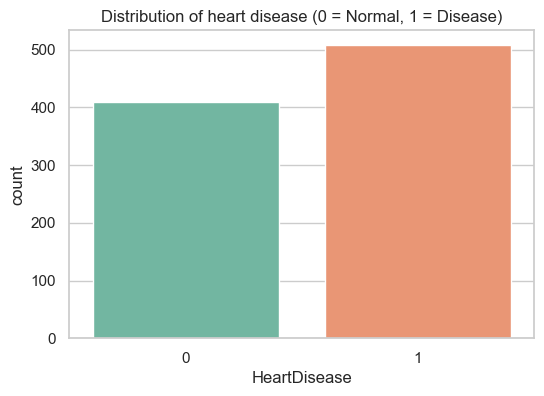

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HeartDisease', palette='Set2')
plt.title('Distribution of heart disease (0 = Normal, 1 = Disease)')
plt.show()

print(df['HeartDisease'].value_counts(normalize=True) * 100)

We can see that the distribution is overall balanced in terms of the heart disease condition, and our observations will be statistically relevant.

Now, let's check the demographics of our patients, to see for whom our analysis will be applicable:

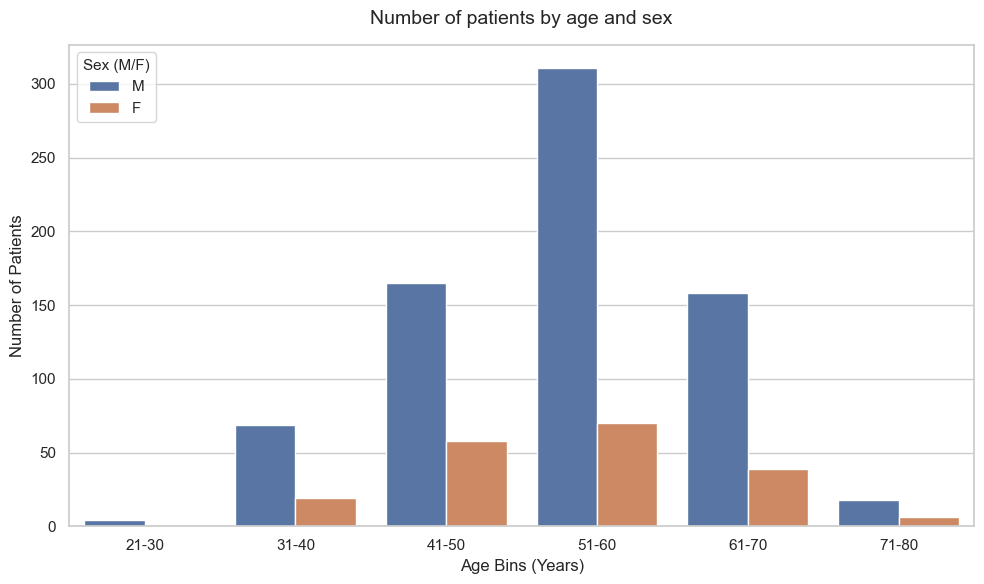

In [26]:
# Set bins
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['21-30', '31-40', '41-50', '51-60', '61-70', '71-80']
df['Age_Bin'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Create the countplot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age_Bin', hue='Sex')

# Add labels and titles
plt.title('Number of patients by age and sex', fontsize=14, pad=15)
plt.xlabel('Age Bins (Years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Sex (M/F)', title_fontsize='11', loc='upper left')

plt.tight_layout()
plt.show()

Our data seems to be heavily focused on ~50 years old males. The inference of the results onto other demographic groups should be executed with extreme caution.

## 4. Bivariate & Multivariate Analysis (Features vs. Target)
Now, the core of our storyline: how do the patient characteristics relate to heart disease?

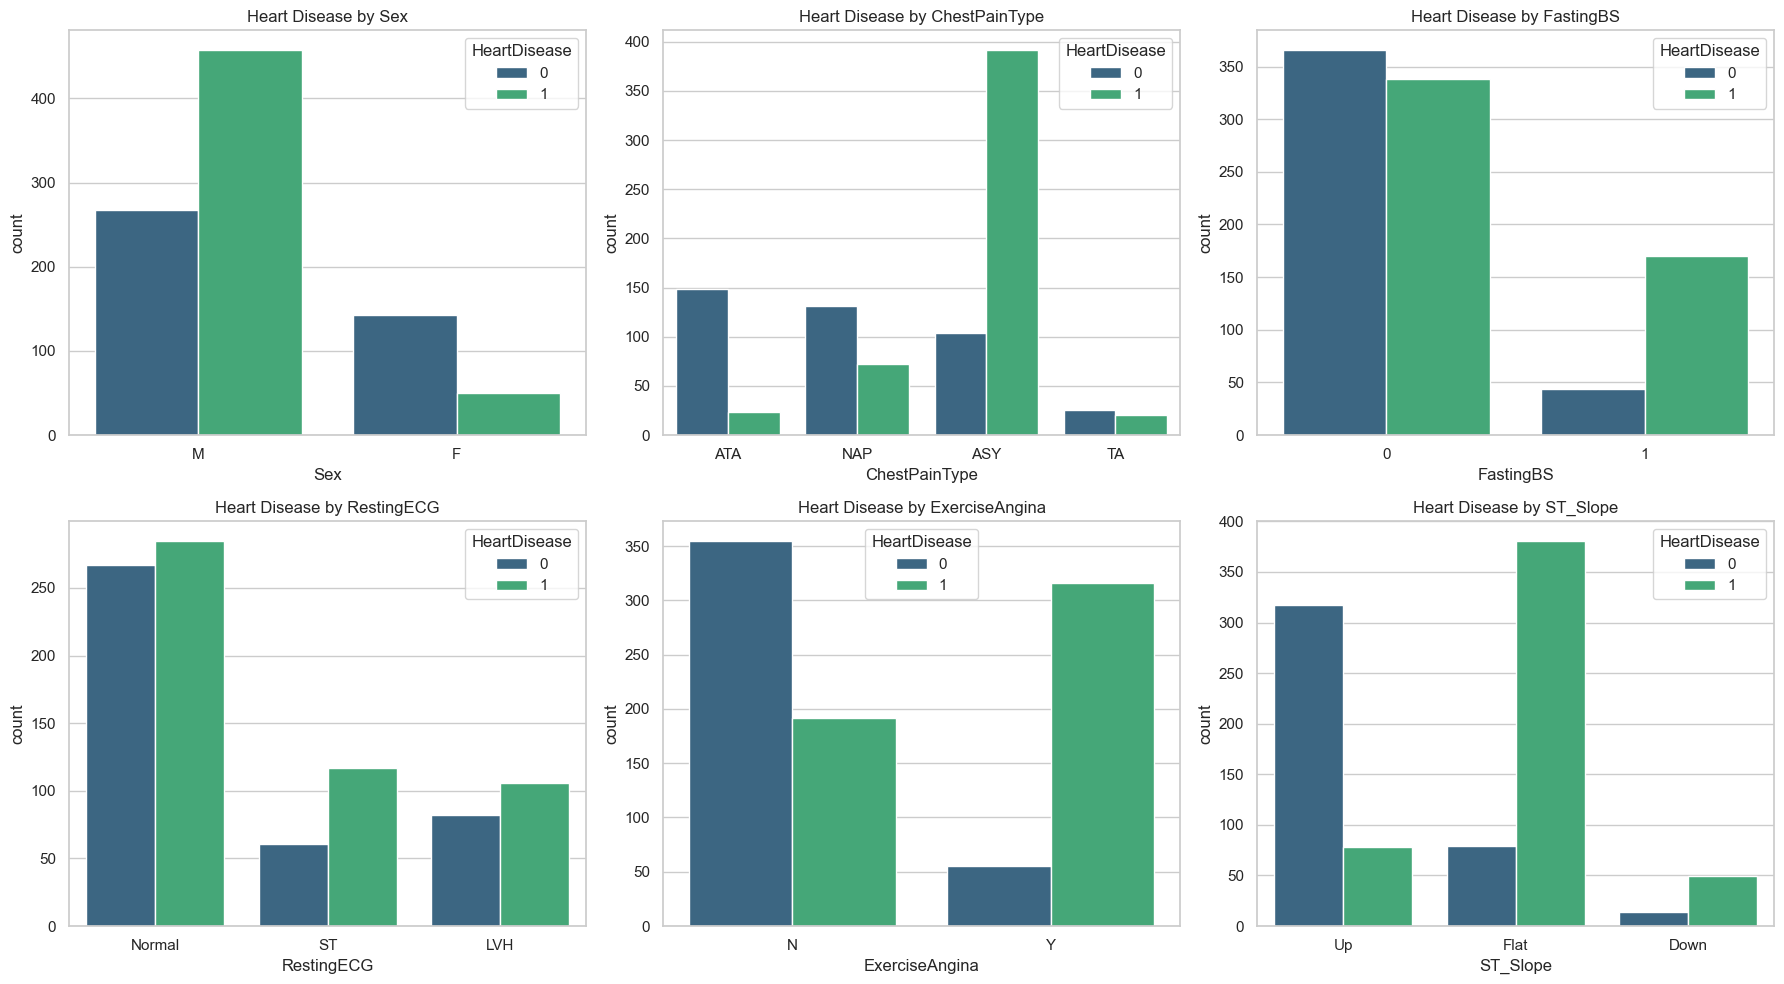

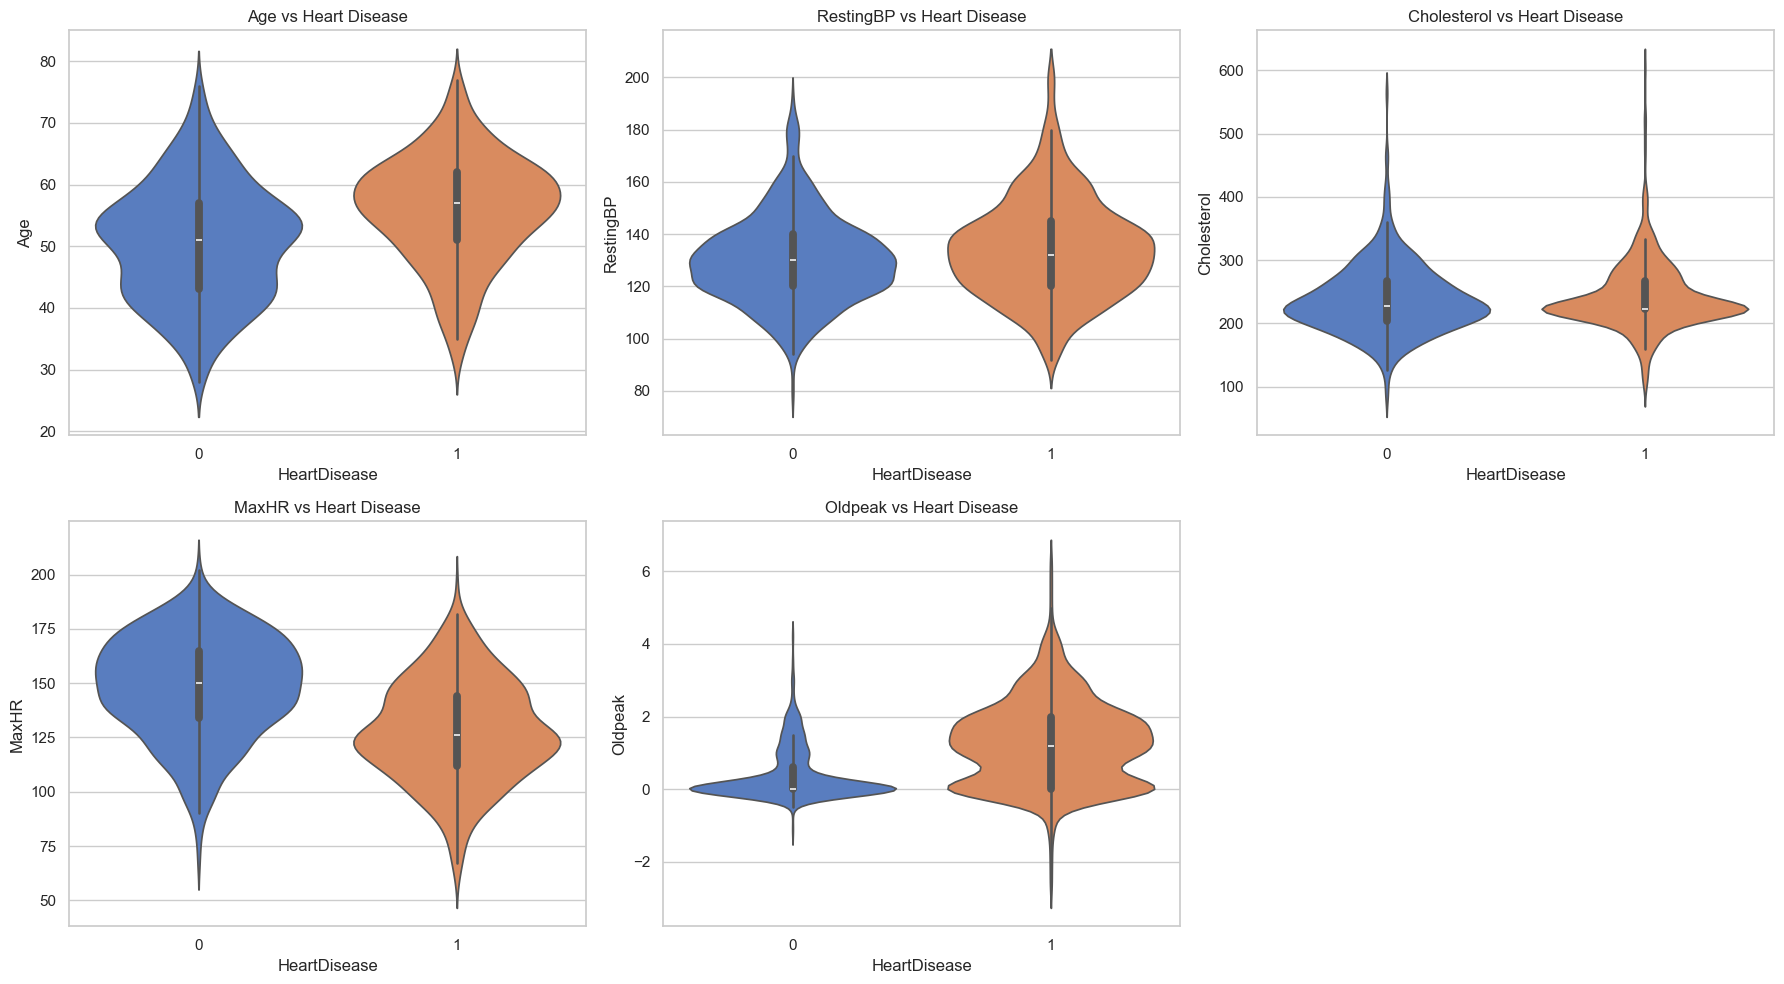

In [28]:
# 1. Categorical Features vs Heart Disease
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, col in enumerate(categorical_cols):
    row, ax_col = idx // 3, idx % 3
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[row, ax_col], palette='viridis')
    axes[row, ax_col].set_title(f'Heart Disease by {col}')
plt.tight_layout()
plt.show()

# 2. Numerical Features vs Heart Disease
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, col in enumerate(numerical_cols):
    row, ax_col = idx // 3, idx % 3
    
    # Replaced boxplot with violinplot
    sns.violinplot(data=df, x='HeartDisease', y=col, ax=axes[row, ax_col], palette='muted')
    
    axes[row, ax_col].set_title(f'{col} vs Heart Disease')

fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

We immediately can see that proportion of disease among men and women is almost inverted. However, we need to be cautious with such observations, as we have established it before that men are over-represented in this dataset.

For the chest pain we can see that all three types of angina-induced chest pain have much lower number of heart disease cases, but we must remember that it is patients' data that should not be extrapolated to the general public: those are medical centers' patients, and overlap of multiple diagnosed diseases should be minority. Another reason for not extrapolating this observation as "absence of chest pain is dangerous" is because especially dangerous cases of [heart diseases](https://www.ncbi.nlm.nih.gov/books/NBK536915/) can occur without chest pain, and probability of such patients from specialized medical centers entering this dataset is higher than for regular population. 

Other bar charts seem to have more or less predictable observations, of heart disease correlating with high blood sugar, exercise-induced angina, or wrong ST slope (not upward) during exercises. Violin plots also mostly show that heart disease patients tend to be older and with slightly higher distribution of resting BP, but also they seem to have less deviating cholesterol levels. Oldpeak values shows significantly different picture in heart disease patients, what is expected, as it signifies ST depression in ECG results and associated with [Ischemic Heart Disease](https://pmc.ncbi.nlm.nih.gov/articles/PMC7359984/).

### Digging Deeper: Multivariate analysis
Let's look at the correlation between all our numerical variables. We can also see how age, heart rate, and heart disease interact.

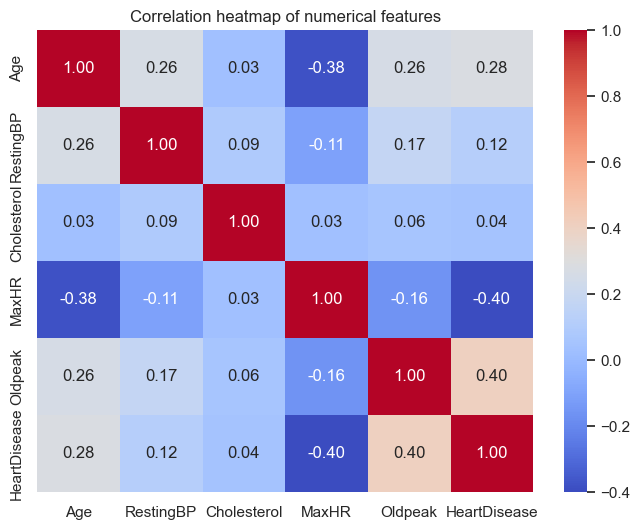

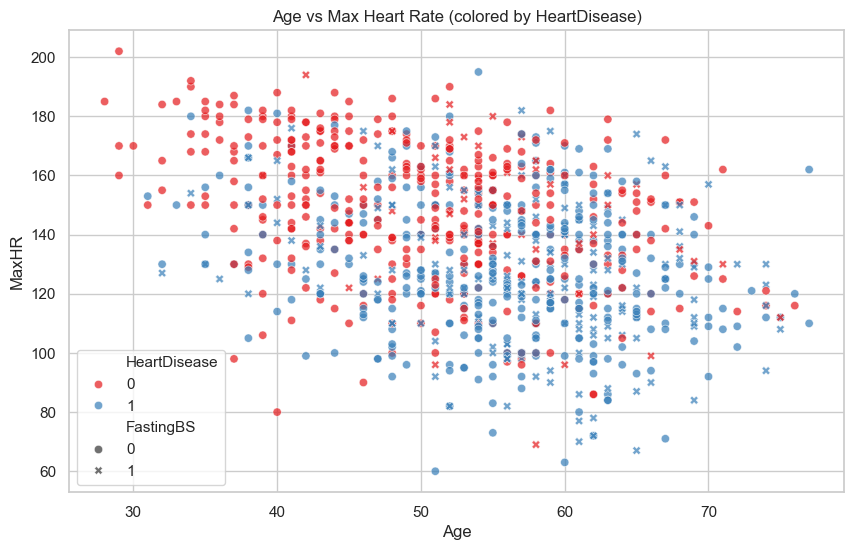

In [29]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation heatmap of numerical features")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='MaxHR', hue='HeartDisease', style='FastingBS', palette='Set1', alpha=0.7)
plt.title("Age vs Max Heart Rate (colored by HeartDisease)")
plt.show()

In multivariate analysis we can see that maximum heart rate under stress strongly negatively correlates both with heart disease and age, and Oldpeak correlates with disease as well, just like we have observed it in the violin plot. Most likely lower MaxHR is caused by early finish of physical stress test due to pain or dangerous reading on the health monitoring equipment. So, it seems that physical exercises for stress-testing heart performance instead of writing homeworks might actually be a wise choice to prevent heart diseases.

Visualizing it with age and other healthy lifestyle-associated parameter, blood sugar, we can see diagonal distribution, as when we move towards the right side with older age, we see more heart disease incidents, lower maximal heart rate, and more cases of elevated blood sugar. Without any surprises, eating less and exercising more seems to be the opposite trend to old age and having diseases.  

## 5. Feature Engineering & Variable Encoding
To prepare this data for a Machine Learning model, we need to convert categorical text (like 'M', 'F', 'ASY') into numbers.
We can also create a new feature based on age.

In [30]:
# Age binning
bins = [0, 40, 55, 65, 100]
labels = ['Young Adult', 'Middle-Aged', 'Senior', 'Elderly']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Encoding categorical variables
# For binary categories with no specific order (Sex, ExerciseAngina) -> Label Encoding / Mapping
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})

# For categories with more than 2 unordered classes -> One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope', 'AgeGroup'], drop_first=True)

display(df_encoded.head())

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,Age_Bin,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,AgeGroup_Middle-Aged,AgeGroup_Senior,AgeGroup_Elderly
0,40,1,140,289,0,172,0,0.0,0,31-40,True,False,False,True,False,False,True,False,False,False
1,49,0,160,180,0,156,0,1.0,1,41-50,False,True,False,True,False,True,False,True,False,False
2,37,1,130,283,0,98,0,0.0,0,31-40,True,False,False,False,True,False,True,False,False,False
3,48,0,138,214,0,108,1,1.5,1,41-50,False,False,False,True,False,True,False,True,False,False
4,54,1,150,195,0,122,0,0.0,0,51-60,False,True,False,True,False,False,True,True,False,False


## 6. Conclusions and moral of the story

**What does this dataset teach us?**
1. **Demographics Matter:** Women seem to be underrepresented in this dataset, yet we can cautiously form a hypothesis that potentially heart diseases among them happen less often.
2. **Lifestyle Matters:** good physical shape and low blood sugar seem to reduce risk of developing heart disease, as well as more conventional metrics like ECG results. 
3. **Chest Pain is a Major Clue:** Interestingly, patients diagnosed with "Asymptomatic" (ASY) chest pain have the highest rate of heart disease in this dataset. Due to limited representation of this dataset for clinical research centers, it might still infer useful conclusions for doctors, to tell them what kind of patients requires elevated level of attention.
4. **Data Integrity:** We discovered that roughly 172 patients had a recorded cholesterol of `0`, which is a significant medical anomaly (likely standing in for missing data). Imputing these values with the median was necessary to prevent skewed modeling later.

Overall, this dataset provides a clear, medically intuitive picture: older patients, exhibiting exercise angina, high blood sugar, premature finish of physical stress tests, and poor ECG results (abnormal resting ECG, wrong St slope or high ST depression), are at a significantly elevated risk for heart disease. The data is now clean, nicely visualized, encoded, and ready to be fed into a predictive machine learning model.